# Network Science Data - Assignment 3
- Course: PHYS 7332
- Semester: Fall 2024
- Date: November 11, 2024
- Name: Minami Ueda (ueda.m@northeastern.edu)
- Environment: `~/work/conda/graphtool2/`

Answers for Question 1(b)-(d)

## Setup

In [1]:
import networkx as nx
# import community
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'

In [3]:
os.chdir('/work/netsi/ueda.m/network-science-data/assignments/assignment3')
print("working directory:", os.getcwd())

working directory: /work/netsi/ueda.m/network-science-data/assignments/assignment3


***
## Question 1

### Question 1(b)

In [4]:
import graph_tool.all as gt

In [5]:
# Load polblogs dataset
g_polblogs = gt.collection.ns["polblogs"]
g_polblogs

<Graph object, directed, with 1490 vertices and 19090 edges, 4 internal vertex properties, 6 internal graph properties, at 0x2ba2af5c4200>

In [6]:
# Extract largest connected component
g_polblogs_lcc = gt.extract_largest_component(g_polblogs, directed=False)

In [7]:
g_polblogs_lcc

<GraphView object, directed, with 1222 vertices and 19089 edges, 4 internal vertex properties, 6 internal graph properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x2ba2af5ab290, at 0x2ba2b1b4b320>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x2ba2af5ab290, at 0x2ba2b1b6ab10>, False), at 0x2ba2af5ab290>

### Degree-corrected and non-degree-corrected SBM
https://graph-tool.skewed.de/static/doc/demos/inference/inference.html#model-selection

`gt.minimize_blockmodel_dl()` takes an parameter called `state_args`, which is then passed the arguments passed to the state constructor (e.g., `BlockState`).

The details of parameters available for `BlockState` is [listed here](https://graph-tool.skewed.de/static/doc/autosummary/graph_tool.inference.BlockState.html#graph_tool.inference.BlockState). This includes parameters that we use here, such as:
- `B`: Number of blocks.
- `deg_corr`: If True, it will be degree-corrected version.

In [8]:
state_ndc = gt.minimize_blockmodel_dl(
    g_polblogs_lcc,
    state_args=dict(deg_corr=False),
    multilevel_mcmc_args=dict(B_max=2)
)

In [9]:
state_dc  = gt.minimize_blockmodel_dl(
    g_polblogs_lcc,
    state_args=dict(deg_corr=True),
    multilevel_mcmc_args=dict(B_max=2)
)

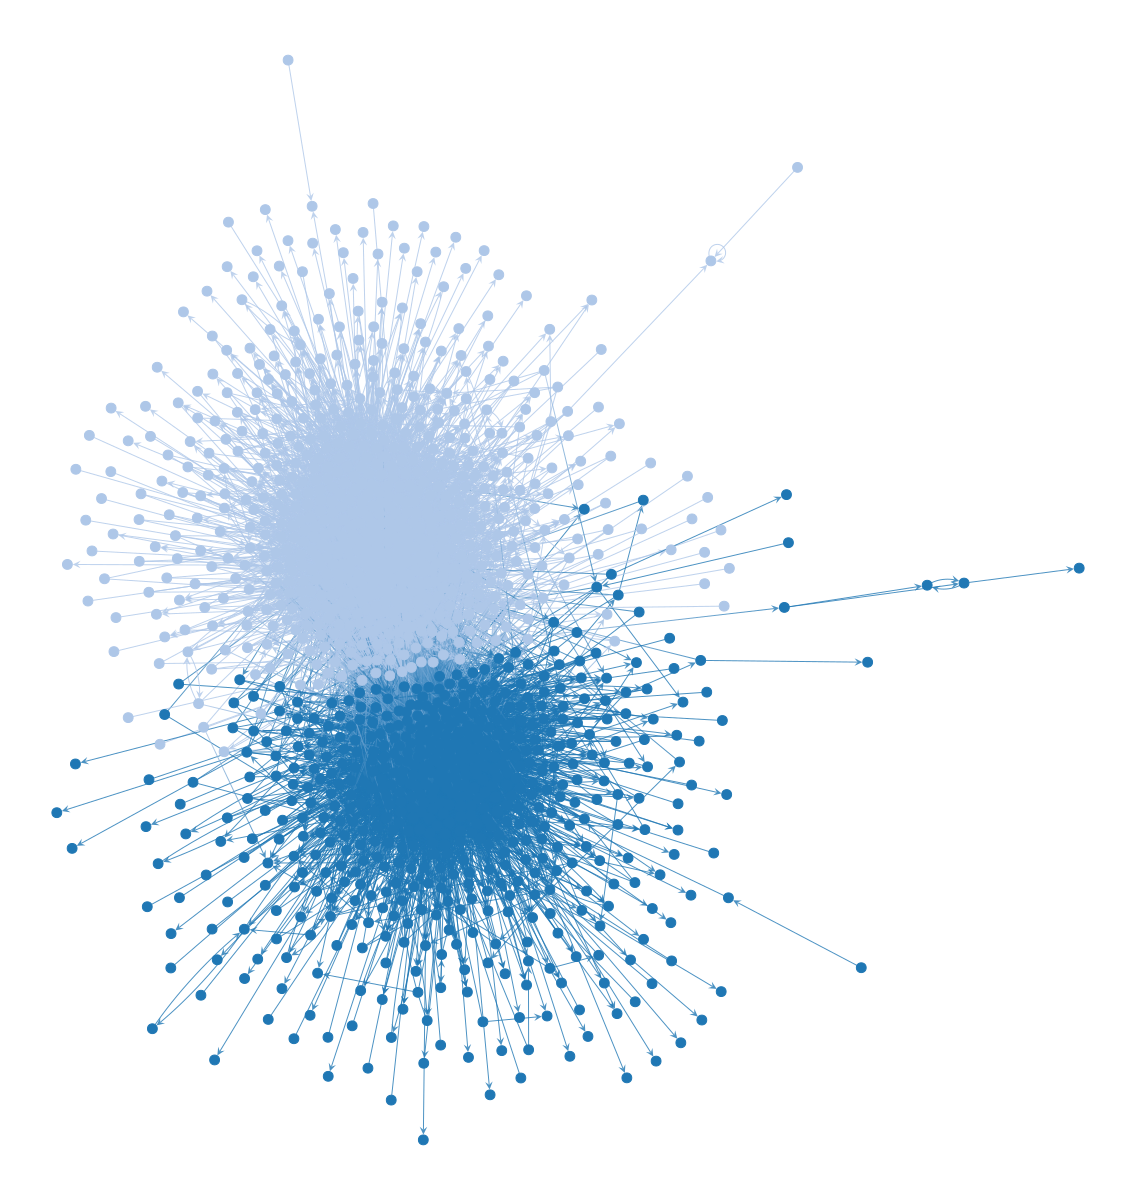

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x2ba2af5ab290, at 0x2ba2b7dfad50>

In [78]:
pos_dc = state_dc.draw()
state_dc.draw(pos=pos_dc, output='figure/polblogs_degree_corrected.pdf')
state_dc.draw(pos=pos_dc, output='figure/polblogs_degree_corrected.png')

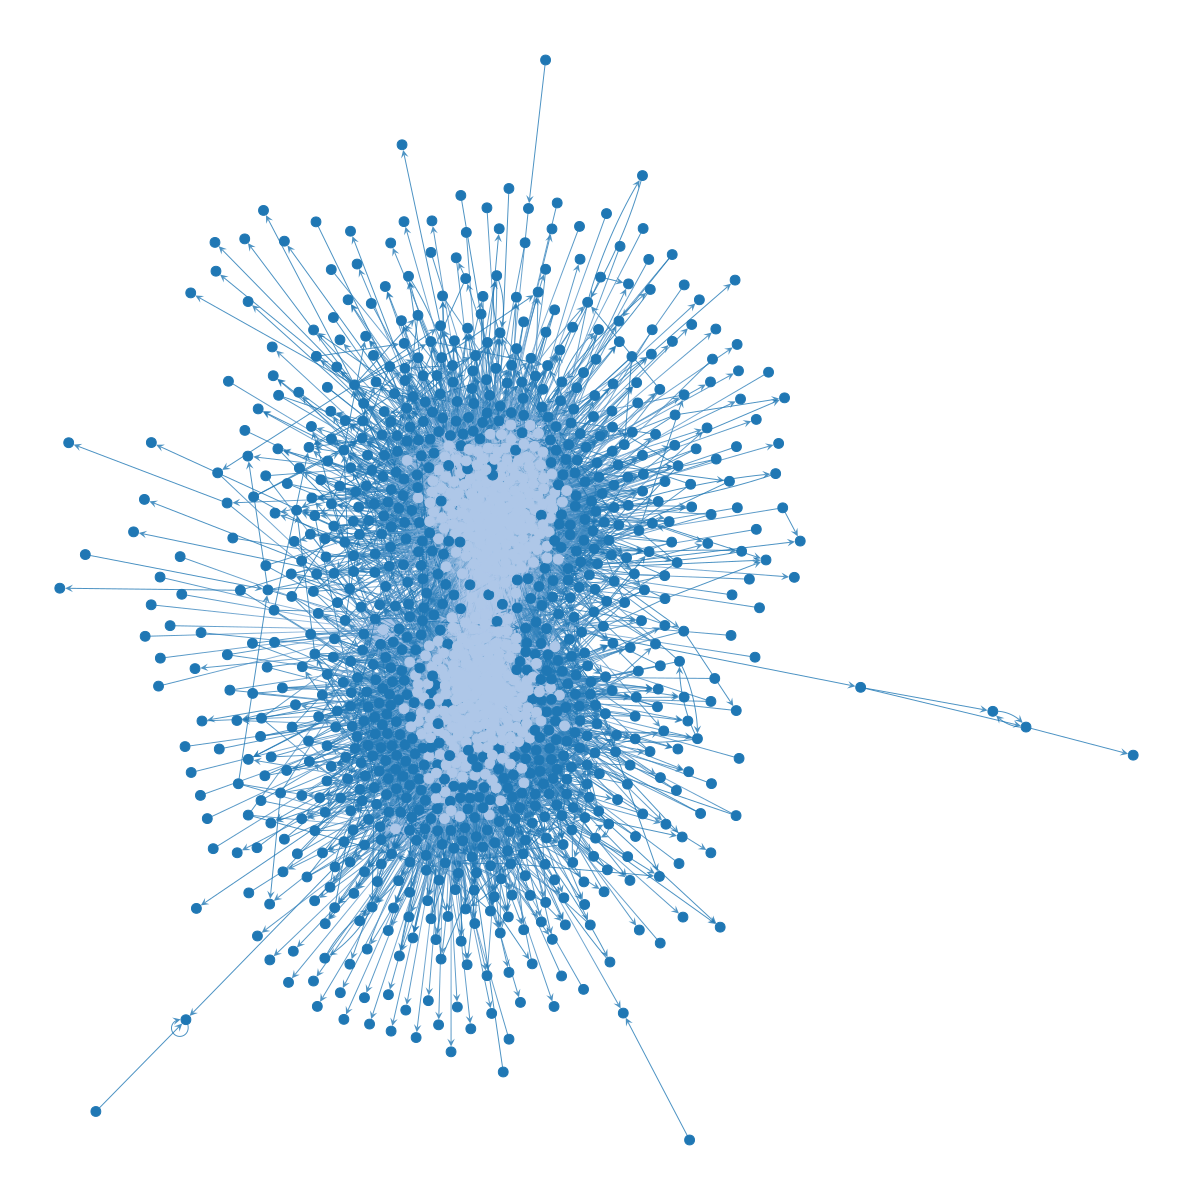

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x2ba2af5ab290, at 0x2ba2b7c70740>

In [79]:
pos_ndc = state_ndc.draw()
state_ndc.draw(pos=pos_ndc, output='figure/polblogs_degree_noncorrected.pdf')
state_ndc.draw(pos=pos_ndc, output='figure/polblogs_degree_noncorrected.png')

### Question 1(c)


#### (i) Description length 
"The description length of a fit can be obtained with the entropy() method. "

https://graph-tool.skewed.de/static/doc/demos/inference/inference.html#inferring-the-best-partition

In [80]:
state_dc.entropy()

63428.9528760646

In [81]:
state_ndc.entropy()

83235.42375314432

#### (ii) Entropy by iteration

In [14]:
from tqdm import tqdm
from tqdm import trange

In [ ]:
# Initialize block state
# We don't use the minimize_blockmodel_dl function here,
# because we're doing the MCMC steps manually in the for loop below
state_dc_2 = gt.BlockState(
    g_polblogs_lcc,
    deg_corr=True,
    B=2
)
state_ndc_2 = gt.BlockState(
    g_polblogs_lcc,
    deg_corr=False,
    B=2
)

In [20]:
description_lengths_dc = []
description_lengths_ndc = []

mcmc_iteration = 1000
for _ in trange(mcmc_iteration):

    # Try different beta

    state_dc_2.mcmc_sweep(niter=1)
    state_ndc_2.mcmc_sweep(niter=1)
    
    # Collect description lengths
    description_lengths_dc.append(state_dc_2.entropy())
    description_lengths_ndc.append(state_ndc_2.entropy())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:08<00:00, 120.86it/s]


In [21]:
import matplotlib.pyplot as plt

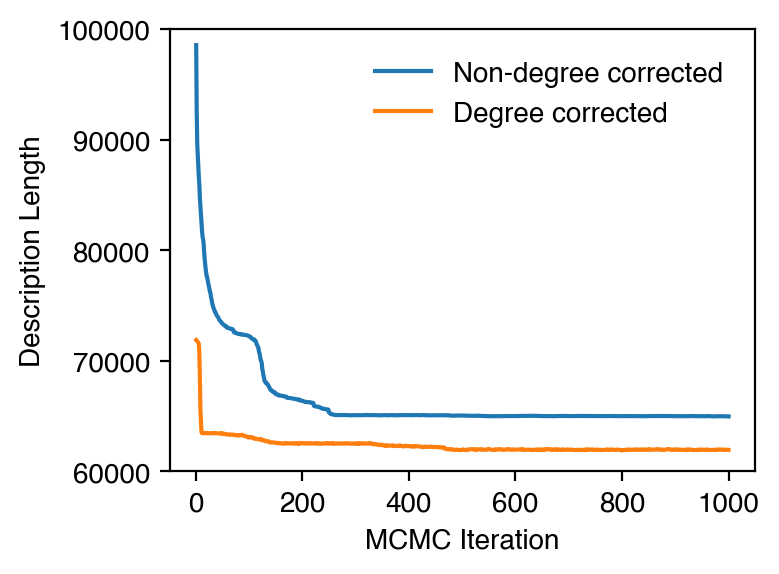

In [85]:
fig, ax = plt.subplots(1,1, figsize=(4,3))

# plotting function
ax.plot(
    range(1,mcmc_iteration+1),
    description_lengths_ndc,
    label="Non-degree corrected"
)
ax.plot(
    range(1,mcmc_iteration+1),
    description_lengths_dc,
    label="Degree corrected"
)


ax.set_title("", loc='left')
ax.set_xlabel("MCMC Iteration")
ax.set_ylabel("Description Length")

ax.set_ylim(60000, 100000)

# ax.set_yscale('log')

# fig.legend(bbox_to_anchor=(0.92, 0.7), frameon=False)
fig.legend(bbox_to_anchor=(0.95, 0.92), frameon=False)

fig.tight_layout()
plt.savefig('figure/description_length_mcmc.pdf', bbox_inches='tight')

plt.show()


In [ ]:
# degree-corrected models are better, because it has lower entropy
print(f"Entropy after {mcmc_iteration:,} MCMC iterations:")
print(f"NDC: {state_ndc_2.entropy():,.2f}")
print(f"DC:  {state_dc_2.entropy():,.2f}")

Entropy after 1,000 MCMC iterations:
NDC: 64,976.37
DC:  61,952.34


In [42]:
entropy_diff = state_dc_2.entropy() - state_ndc_2.entropy()
entropy_diff

-3024.030090806955

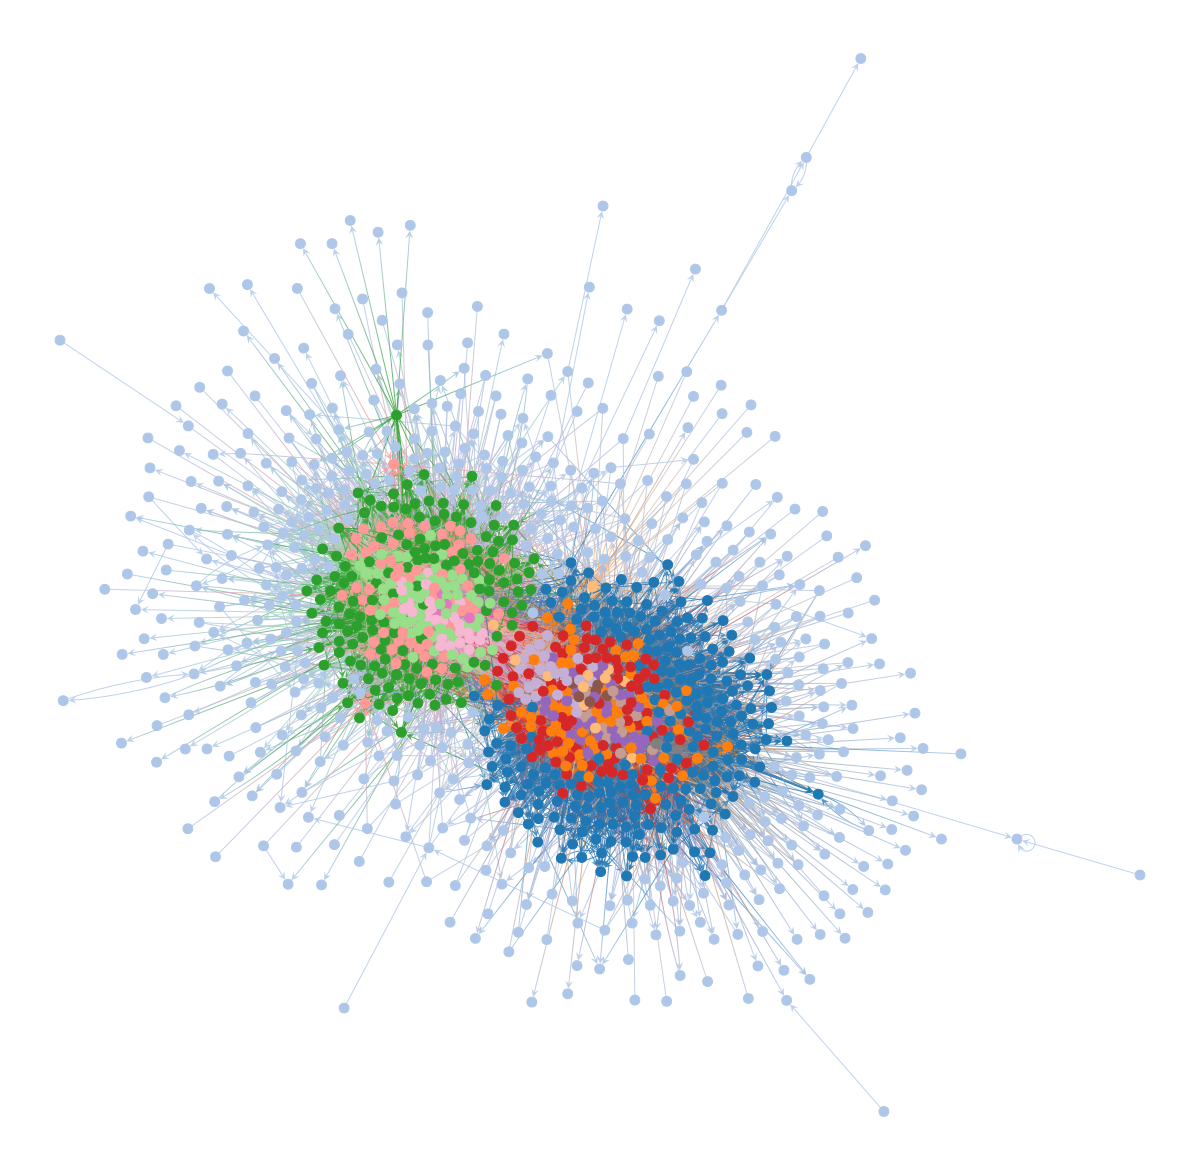

In [76]:
pos_ndc_2 = state_ndc_2.draw()
# state_ndc_2.draw(pos=pos_ndc_2)
#  output='figure/polblogs_degree_noncorrected.pdf'

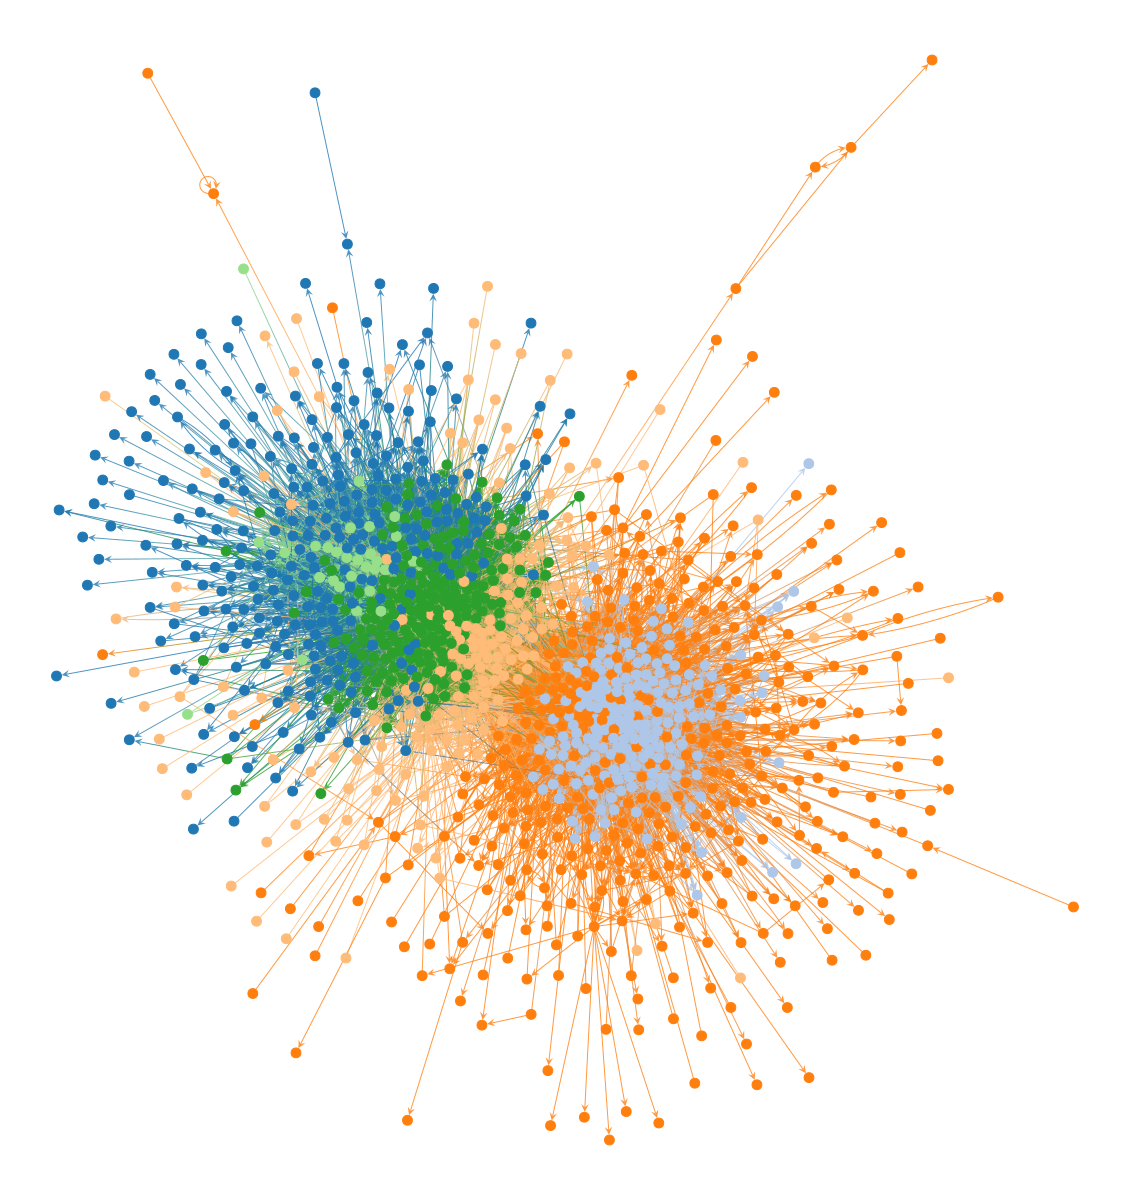

In [77]:
pos_dc_2 = state_dc_2.draw()
# state_ndc_2.draw(pos=pos_ndc_2)
#  output='figure/polblogs_degree_noncorrected.pdf'

In [70]:
delta_seq = [i for i in np.arange(-10, 10, 0.001)]

In [71]:
lambda_seq = [np.power(2.0, -delta) for delta in delta_seq]

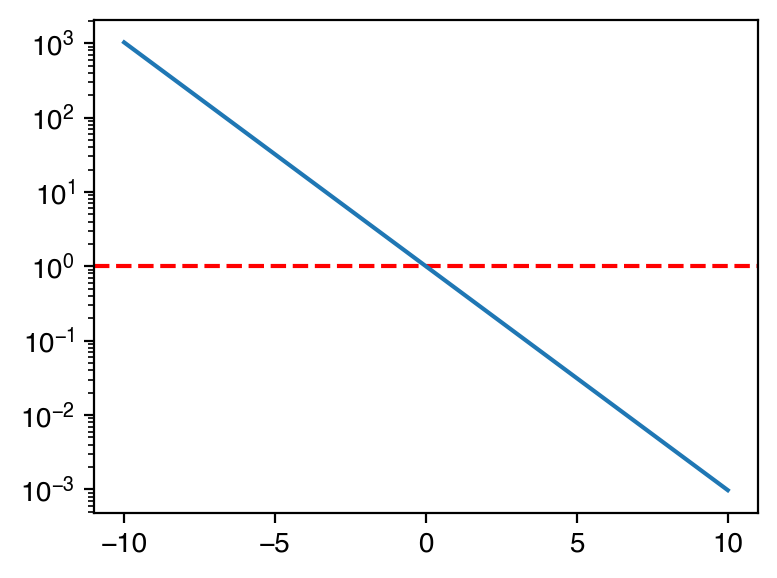

In [74]:
fig, ax = plt.subplots(1,1, figsize=(4,3))

# plot here
ax.plot(delta_seq, lambda_seq, zorder=2)
ax.axhline(y=1, color='r', linestyle='--', zorder=1)

ax.set_title("", loc='left')
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xscale('linear')
ax.set_yscale('log')

fig.tight_layout()

# plt.savefig('figure/fig_name.pdf', bbox_inches='tight')

plt.show()

